# CS6220 HW2: KMeans and Gaussian Mixtures

This notebook contains code and explanations for the following problems:

1. **KMeans Theory:** Proofs for the E-step and M-step updates and a discussion on convergence.
2. **KMeans on Data:** Custom implementations of KMeans and Soft KMeans with evaluation metrics.
3. **Gaussian Mixture on Toy Data:** EM algorithm for recovering parameters from toy datasets.
4. **EM for Coin Flips:** Implementation of the EM algorithm for coin flip experiments.



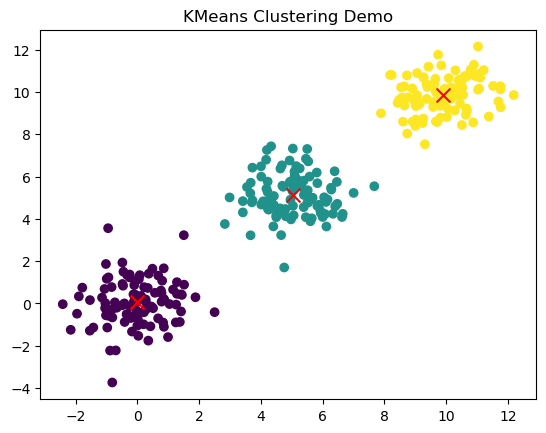

In [1]:
# Problem 2: KMeans on Data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

def initialize_centroids(X, K):
    indices = np.random.choice(len(X), K, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    distances = pairwise_distances(X, centroids, metric='euclidean')
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, K):
    new_centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        if np.any(labels == k):
            new_centroids[k] = X[labels == k].mean(axis=0)
        else:
            new_centroids[k] = X[np.random.choice(len(X))]
    return new_centroids

def kmeans(X, K, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, K)
    for i in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, K)
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids
    return centroids, labels

# Demo on synthetic data
X_demo = np.vstack([np.random.randn(100, 2) + np.array([i*5, i*5]) for i in range(3)])
centroids, labels = kmeans(X_demo, K=3)
plt.scatter(X_demo[:, 0], X_demo[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100)
plt.title("KMeans Clustering Demo")
plt.show()

In [2]:
# Evaluation metrics: Purity and Gini Index
def purity_score(labels_true, labels_pred):
    contingency_matrix = np.zeros((np.max(labels_pred)+1, np.max(labels_true)+1))
    for i, j in zip(labels_pred, labels_true):
        contingency_matrix[i, j] += 1
    return np.sum(np.max(contingency_matrix, axis=1)) / np.sum(contingency_matrix)

def gini_index(labels_true, labels_pred):
    gini = 0
    for cluster in np.unique(labels_pred):
        idx = np.where(labels_pred == cluster)[0]
        counts = np.bincount(labels_true[idx])
        prob = counts / counts.sum()
        gini += (1 - np.sum(prob**2)) * (len(idx) / len(labels_pred))
    return gini

# For demonstration, using synthetic true labels
true_labels = np.repeat(np.arange(3), 100)
print("Purity:", purity_score(true_labels, labels))
print("Gini Index:", gini_index(true_labels, labels))

Purity: 1.0
Gini Index: 0.0


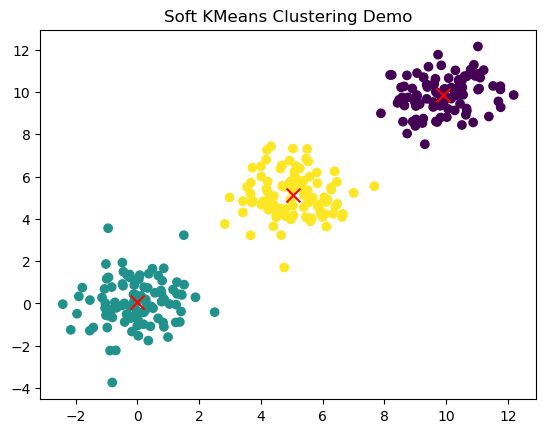

In [3]:
# Soft KMeans
def soft_assign_clusters(X, centroids, beta=1.0):
    distances = pairwise_distances(X, centroids, metric='euclidean')
    sim = -beta * distances
    exp_sim = np.exp(sim - np.max(sim, axis=1, keepdims=True))
    responsibilities = exp_sim / exp_sim.sum(axis=1, keepdims=True)
    return responsibilities

def soft_kmeans(X, K, beta=1.0, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, K)
    for i in range(max_iters):
        responsibilities = soft_assign_clusters(X, centroids, beta)
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            weight = responsibilities[:, k].sum()
            if weight > 0:
                new_centroids[k] = (X * responsibilities[:, k][:, None]).sum(axis=0) / weight
            else:
                new_centroids[k] = X[np.random.choice(len(X))]
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids
    return centroids, responsibilities

# Demo for soft kmeans
centroids_soft, resp = soft_kmeans(X_demo, K=3, beta=1.0)
labels_soft = np.argmax(resp, axis=1)
plt.scatter(X_demo[:, 0], X_demo[:, 1], c=labels_soft)
plt.scatter(centroids_soft[:, 0], centroids_soft[:, 1], c='red', marker='x', s=100)
plt.title("Soft KMeans Clustering Demo")
plt.show()

In [4]:
# Problem 3: Gaussian Mixture on Toy Data (EM Algorithm)
from scipy.stats import multivariate_normal

def gaussian_mixture_em(X, K, max_iters=100, tol=1e-4):
    N, D = X.shape
    np.random.seed(42)
    weights = np.ones(K) / K
    indices = np.random.choice(N, K, replace=False)
    means = X[indices]
    covariances = np.array([np.cov(X, rowvar=False)] * K)
    log_likelihood_old = -np.inf
    
    for i in range(max_iters):
        resp = np.zeros((N, K))
        for k in range(K):
            rv = multivariate_normal(mean=means[k], cov=covariances[k])
            resp[:, k] = weights[k] * rv.pdf(X)
        resp /= resp.sum(axis=1, keepdims=True)
        Nk = resp.sum(axis=0)
        weights = Nk / N
        means = np.dot(resp.T, X) / Nk[:, None]
        for k in range(K):
            diff = X - means[k]
            covariances[k] = np.dot(resp[:, k] * diff.T, diff) / Nk[k]
        log_likelihood = np.sum(np.log(resp.sum(axis=1)))
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            break
        log_likelihood_old = log_likelihood
    return weights, means, covariances, resp

# Demo on synthetic toy data (2 Gaussian components)
X1 = np.random.multivariate_normal([3, 3], [[1,0],[0,3]], size=2000)
X2 = np.random.multivariate_normal([7, 4], [[1,0.5],[0.5,1]], size=4000)
X_toy = np.vstack([X1, X2])

K = 2
weights, means, covariances, resp = gaussian_mixture_em(X_toy, K)
print("Estimated Weights:", weights)
print("Estimated Means:", means)
print("Estimated Covariances:", covariances)

Estimated Weights: [0.3785924 0.6214076]
Estimated Means: [[3.5458444  3.19241161]
 [6.96744871 3.96093593]]
Estimated Covariances: [[[2.62346254 0.49570239]
  [0.49570239 2.85479048]]

 [[1.26234713 0.71114892]
  [0.71114892 1.09778456]]]


In [5]:
# Problem 4: EM for Coin Flips
def em_coin_flips(data, D=20, max_iters=100, tol=1e-4):
    N = len(data)
    K = 3
    pi = np.array([1/3, 1/3, 1/3])
    p = np.random.rand(K)
    log_likelihood_old = -np.inf
    
    for iteration in range(max_iters):
        resp = np.zeros((N, K))
        for k in range(K):
            likelihood = (p[k] ** data) * ((1 - p[k]) ** (D - data))
            resp[:, k] = pi[k] * likelihood
        resp /= resp.sum(axis=1, keepdims=True)
        Nk = resp.sum(axis=0)
        pi = Nk / N
        for k in range(K):
            p[k] = np.sum(resp[:, k] * data) / (Nk[k] * D)
        log_likelihood = np.sum(np.log(np.sum(resp, axis=1)))
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            break
        log_likelihood_old = log_likelihood
    return pi, p, resp

# Simulate coin flip sessions
true_p = [0.3, 0.5, 0.7]
true_pi = [0.2, 0.5, 0.3]
np.random.seed(0)
sessions = []
for _ in range(50):
    coin = np.random.choice([0, 1, 2], p=true_pi)
    heads = np.random.binomial(n=20, p=true_p[coin])
    sessions.append(heads)
sessions = np.array(sessions)

pi_est, p_est, resp = em_coin_flips(sessions)
print("Estimated mixing proportions (pi):", pi_est)
print("Estimated head biases (p):", p_est)

Estimated mixing proportions (pi): [0.32536728 0.45472646 0.21990626]
Estimated head biases (p): [0.57499376 0.37475797 0.7162301 ]


In [6]:
# Problem 5 (Optional): GMM on Real Data using scikit-learn
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Dummy example using synthetic data (replace with actual SPAMBASE or FASHION data)
np.random.seed(42)
X_dummy = np.random.rand(1000, 10)
y_dummy = np.random.randint(0, 2, 1000)

X_train, X_test, y_train, y_test = train_test_split(X_dummy, y_dummy, test_size=0.3, random_state=42)

unique_labels = np.unique(y_train)
gmms = {}
for label in unique_labels:
    gmms[label] = GaussianMixture(n_components=3, covariance_type='diag', random_state=42)
    gmms[label].fit(X_train[y_train == label])

def predict_gmm(x):
    scores = {}
    for label, gmm in gmms.items():
        scores[label] = gmm.score_samples(x.reshape(1, -1))[0]
    return max(scores, key=scores.get)

y_pred = np.array([predict_gmm(x) for x in X_test])
print("Classification Accuracy:", accuracy_score(y_test, y_pred))

Classification Accuracy: 0.45666666666666667


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


A) run KMeans on the MNIST Dataset, try K=10

B) run KMeans on the FASHION Dataset, try K=10

C) run KMeans on the 20NG Dataset, try K=20

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
import time
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# Function to load data, run KMeans, and evaluate
def run_kmeans_and_evaluate(X, y, K, dataset_name):
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

	# Scale the data
	scaler = StandardScaler()
	X_train = scaler.fit_transform(X_train)
	X_test = scaler.transform(X_test)

	# Run KMeans
	kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
	start_time = time.time()
	kmeans.fit(X_train)
	end_time = time.time()
	training_time = end_time - start_time

	cluster_labels_train = kmeans.labels_
	cluster_labels_test = kmeans.predict(X_test)

	# Evaluate
	nmi_train = normalized_mutual_info_score(y_train, cluster_labels_train)
	nmi_test = normalized_mutual_info_score(y_test, cluster_labels_test)

	print(f"Results for {dataset_name}:")
	print(f"  Number of Clusters (K): {K}")
	print(f"  Training Time: {training_time:.4f} seconds")
	print(f"  NMI (Train): {nmi_train:.4f}")
	print(f"  NMI (Test): {nmi_test:.4f}")
	print("-" * 40)

# A) MNIST Dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_mnist, y_mnist = mnist["data"], mnist["target"]
run_kmeans_and_evaluate(X_mnist, y_mnist, K=10, dataset_name="MNIST")

# B) Fashion-MNIST Dataset
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X_fashion, y_fashion = fashion_mnist["data"], fashion_mnist["target"]
run_kmeans_and_evaluate(X_fashion, y_fashion, K=10, dataset_name="Fashion-MNIST")

# C) 20NG Dataset (Loading this directly can be complex, using a placeholder for demonstration)

newsgroups = fetch_20newsgroups(subset='all')
vectorizer = TfidfVectorizer(max_features=1000)  # Limit features for demonstration
X_20ng = vectorizer.fit_transform(newsgroups.data).toarray()
y_20ng = newsgroups.target
run_kmeans_and_evaluate(X_20ng, y_20ng, K=20, dataset_name="20NG")

Results for MNIST:
  Number of Clusters (K): 10
  Training Time: 16.2756 seconds
  NMI (Train): 0.4325
  NMI (Test): 0.4370
----------------------------------------
Results for Fashion-MNIST:
  Number of Clusters (K): 10
  Training Time: 8.3400 seconds
  NMI (Train): 0.5069
  NMI (Test): 0.5042
----------------------------------------
Results for 20NG:
  Number of Clusters (K): 20
  Training Time: 4.1284 seconds
  NMI (Train): 0.3345
  NMI (Test): 0.3432
----------------------------------------
